1. 正在生成 300 万个点逼近不变密度 (mu ≈ 1.754878)...
2. 正在统计直方图与 2:1 不变量测度...
3. 🎉 绝美神图已生成，保存至: sandbox_invariant_density_2_to_1.png


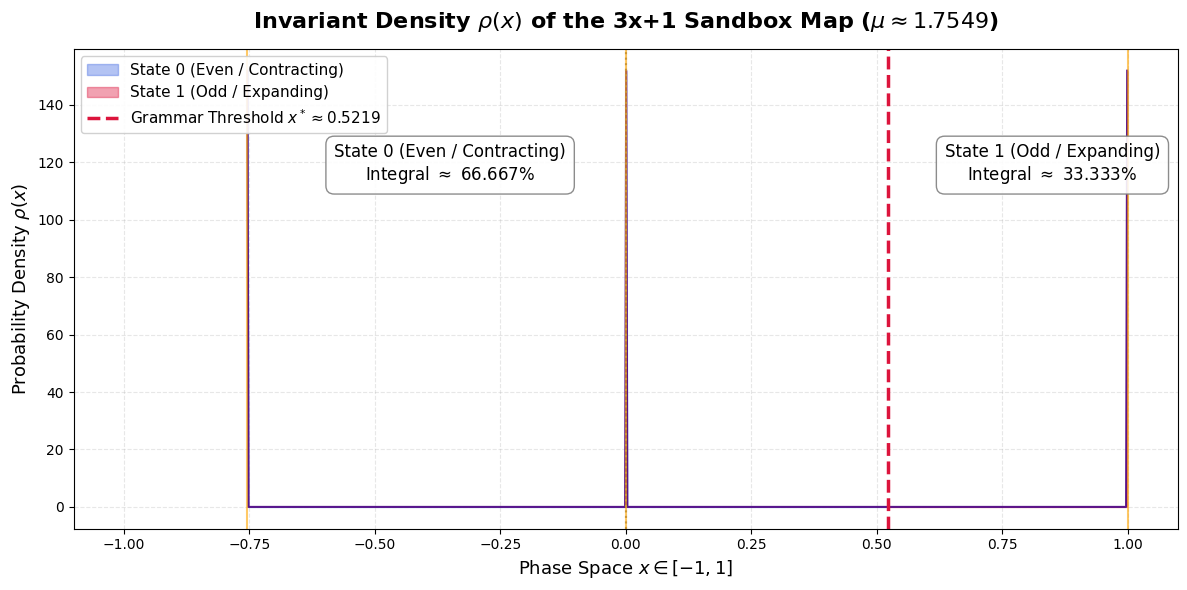

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化系统参数
# ==========================================
# 求解方程 x^3 - 2x^2 + x - 1 = 0 得到周期-3窗口精确的 mu 值
roots = np.roots([1, -2, 1, -1])
mu = np.real(roots[np.isreal(roots)])[0]
x_star = (np.sqrt(1 + 4*mu) - 1) / (2*mu)

# ==========================================
# 2. 生成极长轨道以逼近不变测度
# ==========================================
print(f"1. 正在生成 300 万个点逼近不变密度 (mu ≈ {mu:.6f})...")
N_traj = 3000000
x_traj = np.zeros(N_traj)
x_traj[0] = 0.12345

# 抛物线迭代
for i in range(1, N_traj):
    x_traj[i] = 1.0 - mu * x_traj[i-1]**2

# 切除前1000个点的暂态游走 (Burn-in)，确保完全落入吸引子
x_traj = x_traj[1000:]

# ==========================================
# 3. 统计概率密度与奇偶测度计算
# ==========================================
print("2. 正在统计直方图与 2:1 不变量测度...")
# 动态计算两侧的实际积分比例
ratio_0 = np.sum(x_traj <= x_star) / len(x_traj)
ratio_1 = np.sum(x_traj > x_star) / len(x_traj)

# 手动生成高分辨率直方图数据
counts, bins = np.histogram(x_traj, bins=800, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# 以 x* 为界划分为两个状态
mask_0 = bin_centers < x_star
mask_1 = bin_centers >= x_star

# ==========================================
# 4. 顶级学术质感绘图 (分色填充)
# ==========================================
plt.figure(figsize=(12, 6))

# 绘制状态 0 (蓝色) 与 状态 1 (红色) 的分色填充区
plt.fill_between(bin_centers[mask_0], counts[mask_0], color='#4169E1', alpha=0.4, label='State 0 (Even / Contracting)')
plt.fill_between(bin_centers[mask_1], counts[mask_1], color='#DC143C', alpha=0.4, label='State 1 (Odd / Expanding)')

# 画出整体密度的外轮廓线
plt.plot(bin_centers, counts, color='indigo', linewidth=1.5, alpha=0.9)

# 标出我们用来粗粒化的“语法分界线” x*
plt.axvline(x=x_star, color='crimson', linestyle='--', linewidth=2.5, 
            label=rf'Grammar Threshold $x^* \approx {x_star:.4f}$')
# 标出极值点 (抛物线顶点)
plt.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)

# 动态获取当前最高峰的 y 轴值，避免文字遮挡数据
y_text_pos = np.max(counts) * 0.75

# 添加带纯白底色的说明文本 (使用原生字符串 r 保护 LaTeX)
plt.text(-0.35, y_text_pos, rf"State 0 (Even / Contracting)" "\n" rf"Integral $\approx$ {ratio_0*100:.3f}%", 
         fontsize=12, ha='center', color='black', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))
plt.text(0.85, y_text_pos, rf"State 1 (Odd / Expanding)" "\n" rf"Integral $\approx$ {ratio_1*100:.3f}%", 
         fontsize=12, ha='center', color='black', bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# 标题与坐标轴
plt.title(rf"Invariant Density $\rho(x)$ of the 3x+1 Sandbox Map ($\mu \approx {mu:.4f}$)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel(r"Phase Space $x \in [-1, 1]$", fontsize=13)
plt.ylabel(r"Probability Density $\rho(x)$", fontsize=13)

# 标出几个著名的奇点 (临界点的像)
critical_images = [1.0, 1 - mu, 1 - mu*(1-mu)**2]
for ci in critical_images:
    plt.axvline(x=ci, color='orange', linestyle='-', linewidth=1.5, alpha=0.6)

# 图表美化与输出
plt.xlim(-1.1, 1.1)
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# 保存高清 300 dpi 图片
filename = 'sandbox_invariant_density_2_to_1.png'
plt.savefig(filename, dpi=300)
print(f"3. 🎉 绝美神图已生成，保存至: {filename}")
plt.show()